In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# set up
N = int(1e4)
p = np.array([[0, 0.5, 0.5, 0, 0], [0.25, 0, 0, 0.5, 0.25], [0.75, 0, 0, 0, 0.25], [0, 0, 0, 1, 0], [0, 0, 0, 0, 1]])
h = [0.5, 0.625, 0.375]
g = [4, 2, 4]
tau_f = [4, 1.8, 5]
tau_a = [4, 7/3, 3.4]
x = ['U', 'I', 'M']

In [ ]:
# discrete inverse transform
def pick_state(p):
    U = np.random.uniform(0,1)
    if U < p[0]:
        state = 0
    elif U < (p[0] + p[1]):
        state = 1
    elif U < (p[0] + p[1] + p[2]):
        state = 2
    elif U < (p[0] + p[1] + p[2] + p[3]):
        state = 3
    else:
        state = 4

    return state


h_hat = []
g_hat = []
tau_f_hat = []
tau_a_hat = []
times_f = [[], [], []]
times_a = [[], [], []]

for idx, name in enumerate(x):
    times_F = []
    times_A = []

    for _ in range(N):
        state = idx
        steps = 0

        while state < 3: # 
            # choose a next step (0,5) based on row of transition matrix
            state = pick_state(p[state])
            steps += 1

        # made it to folding yippee
        if state == 3:
            times_F.append(steps)
        else: # 4 is aggregating
            # made it to aggregating yippee
            times_A.append(steps)

    h_hat_new = len(times_F)/N
    tau_f_hat_new = np.mean(times_F)
    tau_a_hat_new = np.mean(times_A)
    g_hat_new = (h_hat_new * tau_f_hat_new) + (1-h_hat_new)*tau_a_hat_new
    h_hat.append(h_hat_new)
    g_hat.append(g_hat_new)
    tau_f_hat.append(tau_f_hat_new)
    tau_a_hat.append(tau_a_hat_new)
    times_f[idx] = times_F
    times_a[idx] = times_A


In [18]:
# print results
print(f"{'State':<5} | {'h_hat':<6} | {'g_hat':<6} | {'tau_F':<6} | {'tau_A'}")
print("-" * 45)
for idx, name in enumerate(x):
    print(f"{name:<5} | {h_hat[idx]:<5.4f} | {g_hat[idx]:<5.4f} | {tau_f_hat[idx]:<5.4f} | {tau_a_hat[idx]:.4f}")

State | h_hat  | g_hat  | tau_F  | tau_A
---------------------------------------------
U     | 0.5089 | 4.0004 | 3.9693 | 4.0326
I     | 0.6242 | 1.9830 | 1.7738 | 2.3305
M     | 0.3660 | 3.9750 | 4.9683 | 3.4016


In [ ]:
# analytic results

# block of lumped transition matrix on {U,I,M} (first three rows and columns)
Q = p[:3, :3]
# block from {U,I,M} to {F,A} (first three rows and last three columns)
R = p[:3, 3:]
n_vals = np.arange(1,16)
pmf_f = [(np.linalg.matrix_power(Q, n-1) @ R)[1,0] / 0.625 for n in n_vals]
pmf_a = [(np.linalg.matrix_power(Q, n-1) @ R)[1,1] / 0.375 for n in n_vals]

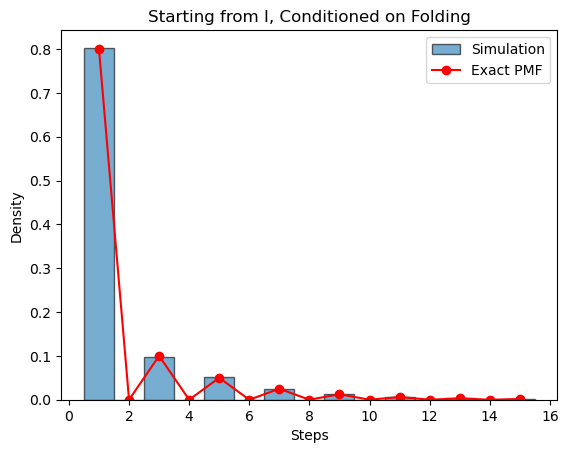

In [53]:
# plotting

plt.hist(times_f[1], bins=np.arange(0.5, 16.5, 1.0), density=True, alpha=0.6, edgecolor='black', label='Simulation')
plt.plot(n_vals, pmf_f, 'ro-', label='Exact PMF')
plt.xlabel('Steps')
plt.ylabel('Density')
plt.title('Starting from I, Conditioned on Folding')
plt.legend()


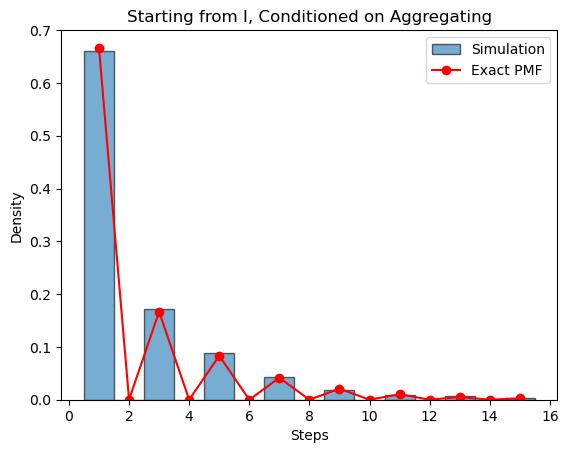

In [54]:
plt.hist(times_a[1], bins=np.arange(0.5, 16.5, 1.0), density=True, alpha=0.6, edgecolor='black', label='Simulation')
plt.plot(n_vals, pmf_a, 'ro-', label='Exact PMF')
plt.xlabel('Steps')
plt.ylabel('Density')
plt.title('Starting from I, Conditioned on Aggregating')
plt.legend()